# Final Project Part 2

## Section 1:

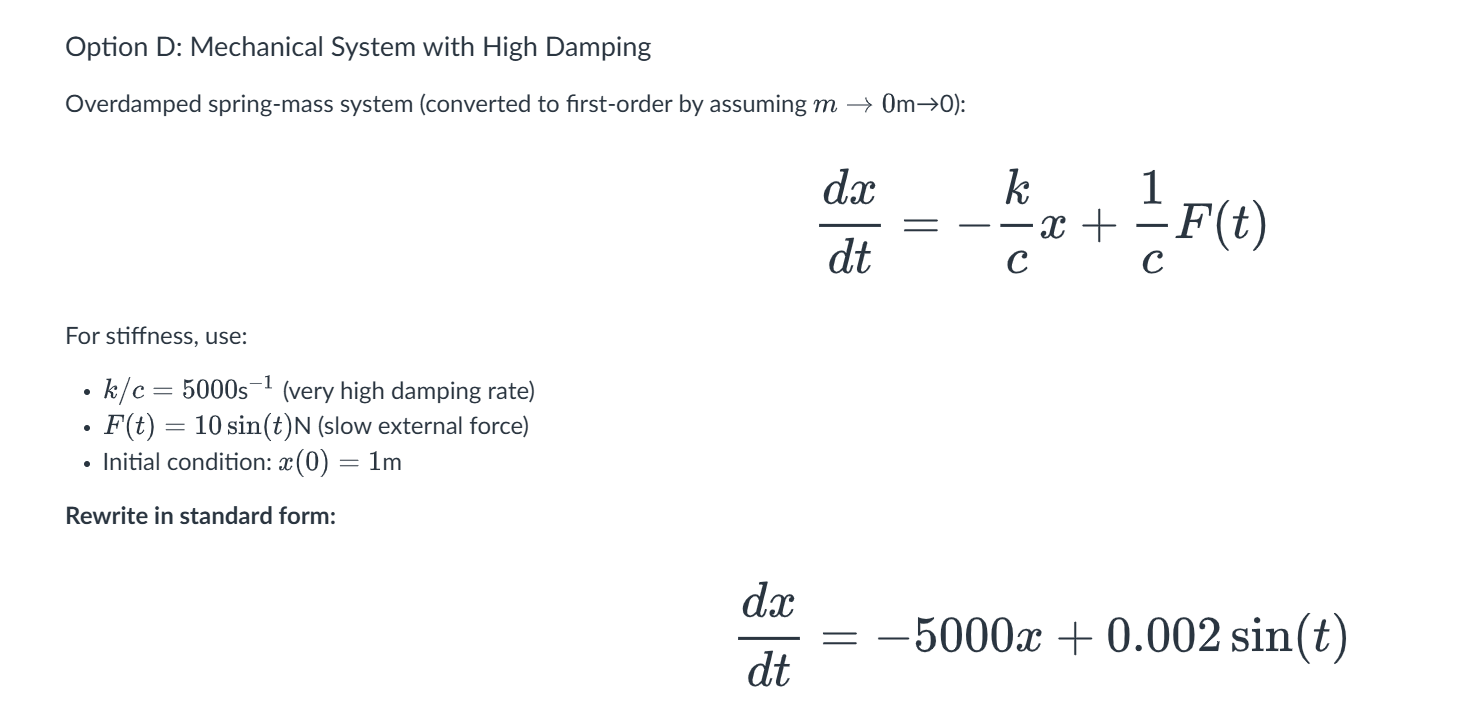

The system that I picked models a mass attached to a spring and damper, where the mass is so small relative to the damping that inertia can be ignored entirely. 

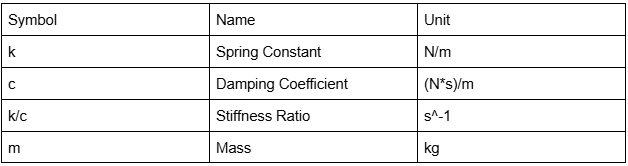

Hydraulic dampers and shock absorbers in vehicles, aircraft landing gear, and civil structures like bridge bearings all operate  near the overdamped range on purpose.This is the result of Engineers designing them to suppress vibration as fast as possible.

## Section 2: 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
# dx/dt = -5000x + 0.002*sin(t)
def f(t, x):
    return -5000.0 * x + 0.002 * np.sin(t)

In [3]:
# Exact analytical solution (for comparison)
# Using integrating factor: y(t) = e^{-λt}*y0 + Integral e^{-λ(t-s)} g(s) ds
# With λ=5000, g(t)=0.002*sin(t), y0=1
def exact(t):
    lam = 5000.0
    A =  0.002 * (-lam) / (lam**2 + 1)   # cos(t) coefficient
    B =  0.002 * 1.0    / (lam**2 + 1)   # sin(t) coefficient
    C = 1.0 - A                            # constant from x(0)=1
    return C * np.exp(-lam * t) + A * np.cos(t) + B * np.sin(t)

In [4]:
def forward_euler(f, t0, y0, h, t_end):
    t, y = t0, y0
    ts, ys = [t], [y]
    while t < t_end - 1e-12:
        y = y + h * f(t, y)
        t = t + h
        ts.append(t)
        ys.append(y)
    return np.array(ts), np.array(ys)
 
ts, xs = forward_euler(f, t0=0.0, y0=1.0, h=0.1, t_end=10)

 Step       t             x (Euler)
    0    0.00            1.0000e+00
    1    0.10           -4.9900e+02
    2    0.20            2.4900e+05
    3    0.30           -1.2425e+08
    4    0.40            6.2001e+10
    5    0.50           -3.0939e+13
    6    0.60            1.5438e+16
    7    0.70           -7.7038e+18
    8    0.80            3.8442e+21
    9    0.90           -1.9182e+24
   10    1.00            9.5721e+26
   11    1.10           -4.7765e+29
   12    1.20            2.3835e+32
   13    1.30           -1.1893e+35
   14    1.40            5.9348e+37
   15    1.50           -2.9615e+40
   16    1.60            1.4778e+43
   17    1.70           -7.3741e+45
   18    1.80            3.6797e+48
   19    1.90           -1.8362e+51
   20    2.00            9.1624e+53
   21    2.10           -4.5721e+56
   22    2.20            2.2815e+59
   23    2.30           -1.1384e+62
   24    2.40            5.6808e+64
   25    2.50           -2.8347e+67
   26    2.60            1.4

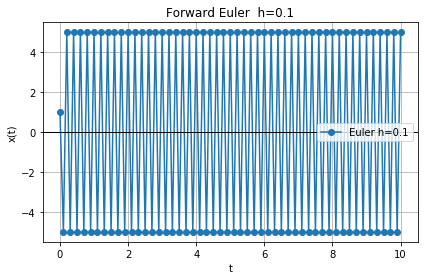

In [5]:
print(f"{'Step':>5}  {'t':>6}  {'x (Euler)':>20}")
for i, (t, x) in enumerate(zip(ts, xs)):
    print(f"{i:>5}  {t:>6.2f}  {x:>20.4e}")
 
plt.plot(ts, np.clip(xs, -5, 5), marker='o', label='Euler h=0.1')
plt.axhline(0, color='k', lw=1)
plt.grid()
plt.xlabel('t'); plt.ylabel('x(t)')
plt.title('Forward Euler  h=0.1')
plt.legend(); plt.tight_layout()

plt.show()

For this particular problem the stiffness ratio is 5000x. This means the fast dynamics are 5000 times faster than the slow dynamics.The result from this stiffness ratio renders this problem as a highly Stiff ODE

For this problem implicit methods are required because we need the ODE to be evaluated at the next time step rather than the current one, which is what we do in  explicit methods. This is because implicit methods are unconditionally stable. Because of this we can set the step size to be determined by accuracy, not stability. The total computational cost of an implicit method on a stiff problem is orders of magnitude lower 

## Section 3: 

Risidual function for my specific problem:

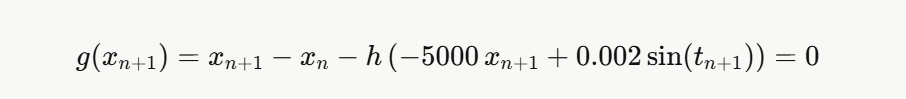

Analytical Derivation of g'(x_{n+1})

Starting from the Residual:

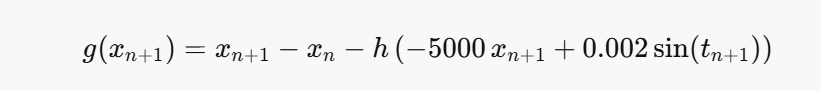

Term by Term Differentiation:

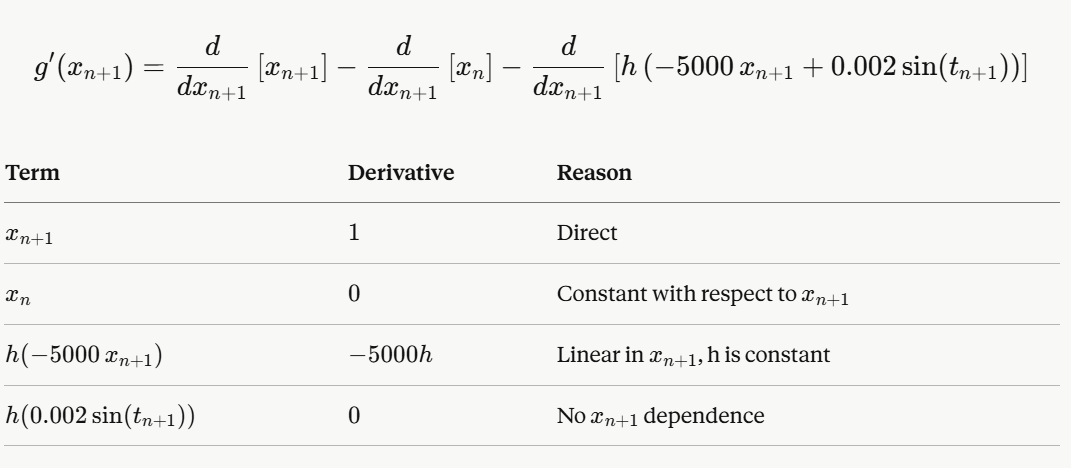

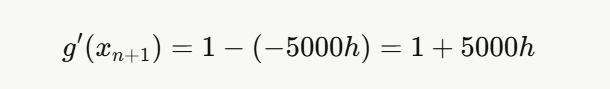

Newton-Raphson update formula:

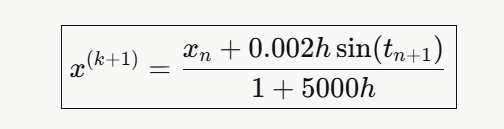

## Section 4:

In [6]:
def dg_dy(h):
    return 1 + 5000 * h

In [7]:
def newton_raphson(y_old, t_new, h, tol=1e-10, max_iter=50):
    y         = y_old
    J         = dg_dy(h)
    residuals = []
    for k in range(max_iter):
        residual = y - y_old - h * f(t_new, y)
        residuals.append(abs(residual))
        y_new = y - residual / J
        if abs(y_new - y) < tol:
            return y_new, k + 1, residuals
        y = y_new
    return y, max_iter, residuals

In [8]:
def backward_euler(f, t0, y0, h, t_end):
    t, y = t0, y0
    ts, ys, iter_counts = [t], [y], []
 
    while t < t_end - 1e-12:
        t_new          = t + h
        y_new, its, _  = newton_raphson(y, t_new, h)
        t, y           = t_new, y_new
        ts.append(t)
        ys.append(y)
        iter_counts.append(its)
 
    return np.array(ts), np.array(ys), iter_counts

In [9]:
ts, ys, _ = backward_euler(f, t0=0.0, y0=1.0, h=0.1, t_end=0.5)
 
print(f"{'Step':>5}  {'t':>6}  {'y (Backward Euler)':>20}")
for i, (t, y) in enumerate(zip(ts, ys)):
    print(f"{i:>5}  {t:>6.2f}  {y:>20.6e}")

 Step       t    y (Backward Euler)
    0    0.00          1.000000e+00
    1    0.10          1.996048e-03
    2    0.20          4.063437e-06
    3    0.30          1.260828e-07
    4    0.40          1.557081e-07
    5    0.50          1.916982e-07


## Section 5:

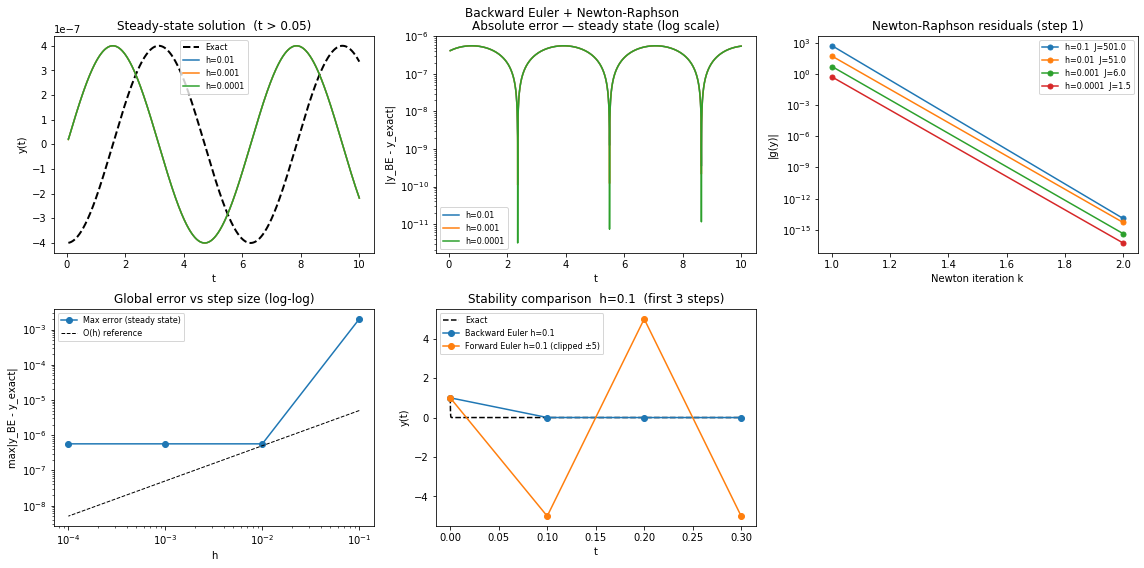

In [19]:
# ── settings ──────────────────────────────────────────────────────────
solution_steps = [0.01, 0.001, 0.0001]
all_steps      = [0.1, 0.01, 0.001, 0.0001]
t_end          = 10.0
t_ss_start     = 0.05          # start of steady-state region (transient gone)
t_fine_full    = np.linspace(0, t_end, 10000)
t_fine_ss      = np.linspace(t_ss_start, t_end, 10000)
 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Backward Euler + Newton-Raphson")
 
# ── plot 1: zoom into steady-state region (transient skipped) ─────────
# y(0)=1 decays to ~0 within 0.001s — zoom to t>0.05 to see forcing
# ── plot 1: steady-state solution ─────────────────────────────────────
ax = axes[0, 0]
ax.plot(t_fine_ss, exact(t_fine_ss), "k--", lw=2, label="Exact")
for h in solution_steps:
    ts, ys, _ = backward_euler(f, 0.0, 1.0, h, t_end)
    mask = ts >= t_ss_start
    ax.plot(ts[mask], ys[mask], lw=1.5, label=f"h={h}")
ax.set_title("Steady-state solution  (t > 0.05)")
ax.set_xlabel("t"); ax.set_ylabel("y(t)")
ax.legend(fontsize=8)
 
# ── plot 2: absolute error over time ──────────────────────────────────
ax = axes[0, 1]
for h in solution_steps:
    ts, ys, _ = backward_euler(f, 0.0, 1.0, h, t_end)
    mask   = ts >= t_ss_start
    errors = np.abs(ys[mask] - exact(ts[mask])).clip(1e-16)
    ax.semilogy(ts[mask], errors, lw=1.5, label=f"h={h}")
ax.set_title("Absolute error — steady state (log scale)")
ax.set_xlabel("t"); ax.set_ylabel("|y_BE - y_exact|")
ax.legend(fontsize=8)
 
# ── plot 3: Newton-Raphson residual convergence ───────────────────────
# Shows residual |g(y^k)| at each Newton iteration for first step
ax = axes[0, 2]
for h in all_steps:
    _, _, residuals = newton_raphson(1.0, h, h, tol=1e-10)
    ax.semilogy(range(1, len(residuals) + 1), residuals,
                marker="o", markersize=5, lw=1.5,
                label=f"h={h}  J={dg_dy(h):.1f}")
ax.set_title("Newton-Raphson residuals (step 1)")
ax.set_xlabel("Newton iteration k"); ax.set_ylabel("|g(y)|")
ax.legend(fontsize=8)
 
# ── plot 4: global error vs step size (log-log) ───────────────────────
ax = axes[1, 0]
global_errors = []
for h in all_steps:
    ts, ys, _ = backward_euler(f, 0.0, 1.0, h, t_end)
    mask = ts >= t_ss_start
    global_errors.append(np.max(np.abs(ys[mask] - exact(ts[mask]))))
ax.loglog(all_steps, global_errors, marker="o", lw=1.5, label="Max error (steady state)")
ax.loglog(all_steps, [h * 5e-5 for h in all_steps], "k--", lw=1, label="O(h) reference")
ax.set_title("Global error vs step size (log-log)")
ax.set_xlabel("h"); ax.set_ylabel("max|y_BE - y_exact|")
ax.legend(fontsize=8)
 
# ── plot 5: stability comparison forward vs backward ──────────────────
ax = axes[1, 1]
h            = 0.1
t_stab_end   = 0.3
t_fine_stab  = np.linspace(0, t_stab_end, 5000)
ts_be, ys_be, _ = backward_euler(f, 0.0, 1.0, h, t_stab_end)
ts_fe, ys_fe    = forward_euler(f, 0.0, 1.0, h, t_stab_end)
ax.plot(t_fine_stab, exact(t_fine_stab), "k--", lw=1.5, label="Exact")
ax.plot(ts_be, ys_be, marker="o", markersize=6, lw=1.5, label=f"Backward Euler h={h}")
ax.plot(ts_fe, np.clip(ys_fe, -5, 5), marker="o", markersize=6, lw=1.5,
        label=f"Forward Euler h={h} (clipped ±5)")
ax.set_title(f"Stability comparison  h={h}  (first 3 steps)")
ax.set_xlabel("t"); ax.set_ylabel("y(t)")
ax.set_ylim(-5.5, 5.5)
ax.legend(fontsize=8)
 
# ── plot 6: empty — reserved ──────────────────────────────────────────
axes[1, 2].axis("off")
 
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()
 

## Section 6:

The computational cose of a numerical ODE solver resides in the number of function evaluations, From t = 0 to t = 10 seconds Forward Euler utilizes 1 function evaluation per step resulting in a total of 25,000 evaluations at the stability limit. Backward Euler with Newton-Raphson does 1 function evaluation per Newton iteration per step. For this linear ODE that is exactly 1 iteration per step. At h = 0.1 this causes 100 evaluations.

Table comparing Euler's Forward vs. Backward:

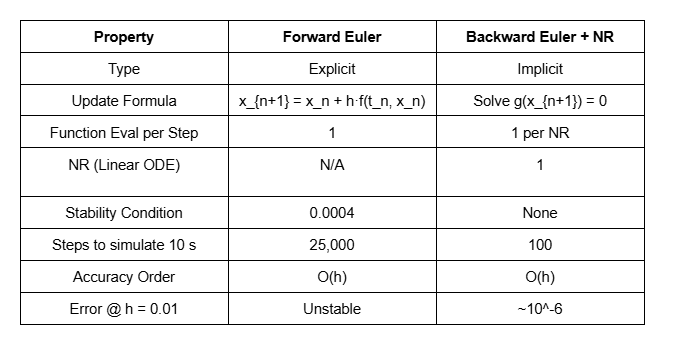

Both methods are O(h) accurate. The tradeoff is not accuracy it is stability vs. cost. Forward Euler results in 25,000 computations for a nearly constant function. This is the culminating issue with using explicit methods on stiff problems such as this one. Backwards Euler allows for h = 0.1 with full stability but the error remains large.The conclusion  that for this system, accuracy in the steady state is cheap with Backward Euler  at h = 0.001 gives an error of ~10^-6 at only 10,000 steps, far fewer than the 25,000 Forward Euler requires just to remain stable. 

Practical Recommendations:

For this specific system — λ = 5000, slow sin(t) forcing, x(0) = 1. To solve this system we need to use backwards Euler with h = 0.001 this will allow us to accomplish a favorable accuracy while still completing 2.5x fewer computations then Forward Euler.

## Section 7

The most significant finding from this investigation was that stiffness is not a property from the solution but rather that it is from the equation itself. The solutions to this set become trivial almost instantly after it is run. Yet, the equation continues to drive extremely small step sizes for the entire duration of the simulation. Backward Euler with Newton-Raphson fixes this completely. By evaluating the stiff term at the next time step rather than the current one, the coefficient lambda = 5000 moves from the numerator to the denominator. The method is unconditionally stable, converges in exactly one Newton iteration per step for this linear ODE, and achieves O(h) accuracy at step sizes 250× larger than Forward Euler can tolerate. 

We should be using explicit methods when the stiffness ratio is small, meaning that the timescales of the equation are comparable. They are simpler to implement with no need for a jacobian. However we should be using implicit methods when the stiffness ratio is large. Meaning that the step size of the explicit method is constrained. 

The biggest challenge was that the initial condition x(0) = 1 decays to ~10^-7 in milliseconds, making the solution appear flat and featureless at any reasonable axis scale. The solution plot was uninformative until the axis was restricted to the steady-state region